Adjacency matrix:
[[1 1 0 1 0 0 1 1 1 0]
 [1 1 0 0 0 0 0 0 1 1]
 [0 0 1 0 1 0 0 0 1 1]
 [1 0 0 1 0 0 0 0 0 0]
 [0 0 1 0 1 1 0 1 1 1]
 [0 0 0 0 1 1 0 0 0 1]
 [1 0 0 0 0 0 1 0 0 0]
 [1 0 0 0 1 0 0 1 0 0]
 [1 1 1 0 1 0 0 0 1 1]
 [0 1 1 0 1 1 0 0 1 1]]


/tmp/ipykernel_518237/615436287.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


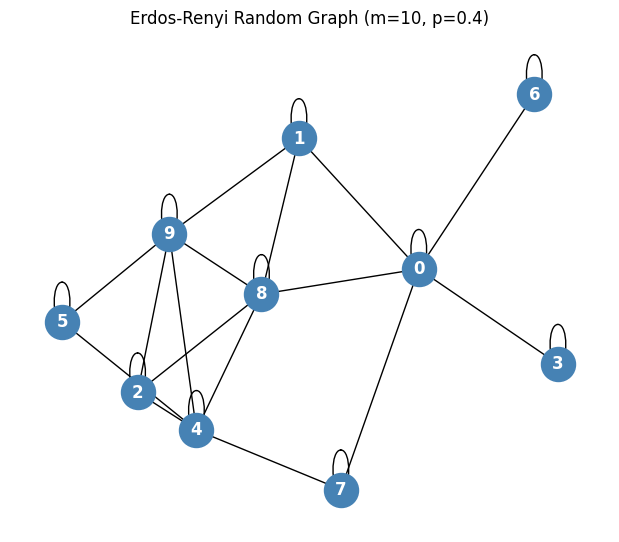

In [15]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from graph import erdos_renyi_graph

seed = 2
m = 10
p = 0.4
A = erdos_renyi_graph(m=m, p=p, seed=seed)

print("Adjacency matrix:")
print(A.astype(int))

G = nx.from_numpy_array(A)
plt.figure(figsize=(6, 5))
nx.draw(G, with_labels=True, node_color="steelblue", node_size=600, font_color="white", font_weight="bold")
plt.title(f"Erdos-Renyi Random Graph (m={m}, p={p})")
plt.tight_layout()
plt.show()



Initial Kemeny: 344335.3526
Final Kemeny:   23.0171
Adjacency matrix:
 [[1 1 0 1 0 0 1 1 1 0]
 [1 1 0 0 0 0 0 0 1 1]
 [0 0 1 0 1 0 0 0 1 1]
 [1 0 0 1 0 0 0 0 0 0]
 [0 0 1 0 1 1 0 1 1 1]
 [0 0 0 0 1 1 0 0 0 1]
 [1 0 0 0 0 0 1 0 0 0]
 [1 0 0 0 1 0 0 1 0 0]
 [1 1 1 0 1 0 0 0 1 1]
 [0 1 1 0 1 1 0 0 1 1]]
Final Q:
 [[0.     0.0206 0.     0.0183 0.     0.     0.0272 0.0191 0.0004 0.    ]
 [0.0206 0.0708 0.     0.     0.     0.     0.     0.     0.0353 0.0254]
 [0.     0.     0.0376 0.     0.0353 0.     0.     0.     0.0199 0.0107]
 [0.0183 0.     0.     0.0415 0.     0.     0.     0.     0.     0.    ]
 [0.     0.     0.0353 0.     0.0232 0.0313 0.     0.0502 0.0147 0.0044]
 [0.     0.     0.     0.     0.0313 0.0263 0.     0.     0.     0.01  ]
 [0.0272 0.     0.     0.     0.     0.     0.0885 0.     0.     0.    ]
 [0.0191 0.     0.     0.     0.0502 0.     0.     0.066  0.     0.    ]
 [0.0004 0.0353 0.0199 0.     0.0147 0.     0.     0.     0.     0.    ]
 [0.     0.0254 0.0107 0.     

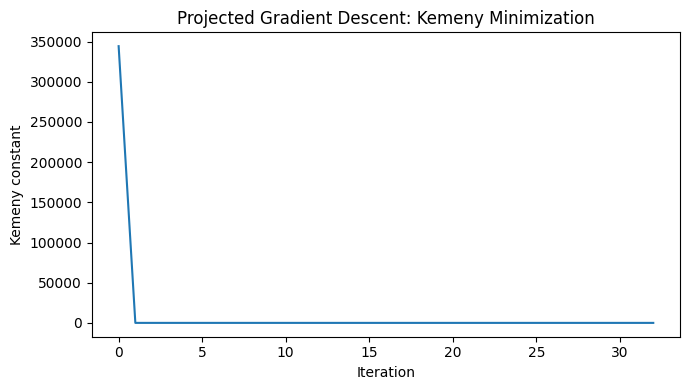

In [16]:
from graph import random_chain
from optimize import _grad_kemeny, make_project_Q_bar, projected_gradient_descent

K_final = np.inf
while K_final > 100:
    # Random stationary distribution
    pi_bar = np.random.dirichlet(5 * np.ones(len(A)))

    # Random initial ergodic flow
    Q0 = random_chain(A, seed=seed)
    project_fn = make_project_Q_bar(A, pi_bar)
    Q0 = project_fn(Q0)

    # Projected gradient descent to minimize the Kemeny constant
    Q_opt, history = projected_gradient_descent(Q0, _grad_kemeny, project_fn, alpha=1e-5, n_iter=100, tol=1e-2)
    K_initial = history[0]
    K_final = history[-1]

print(f"\nInitial Kemeny: {K_initial:.4f}")
print(f"Final Kemeny:   {K_final:.4f}")

print(f"Adjacency matrix:\n {A.astype(int)}")
np.set_printoptions(precision=6, suppress=True)
print(f"Final Q:\n {np.round(Q_opt, 4)}")

print("pi_bar:", np.round(pi_bar, 4))
print(f"Final row sums: {np.round(Q_opt.sum(axis=1), 4)}")
print(f"Final col sums: {np.round(Q_opt.sum(axis=0), 4)}")

plt.figure(figsize=(7, 4))
plt.plot(history)
plt.xlabel("Iteration")
plt.ylabel("Kemeny constant")
plt.title("Projected Gradient Descent: Kemeny Minimization")
plt.tight_layout()
plt.show()


Physical nodes m=10, lifted states n=32
A_lift:
 [[1 1 1 ... 0 0 0]
 [1 1 1 ... 0 0 0]
 [1 1 1 ... 0 0 0]
 ...
 [0 0 0 ... 1 1 1]
 [0 0 0 ... 1 1 1]
 [0 0 0 ... 1 1 1]]

K^lift (initial):    5944.6652
K(Q_opt) [upper bd]: 23.0171

K^lift initial:  5944.6652
K^lift final:    14.3920
K(Q_opt):        23.0171


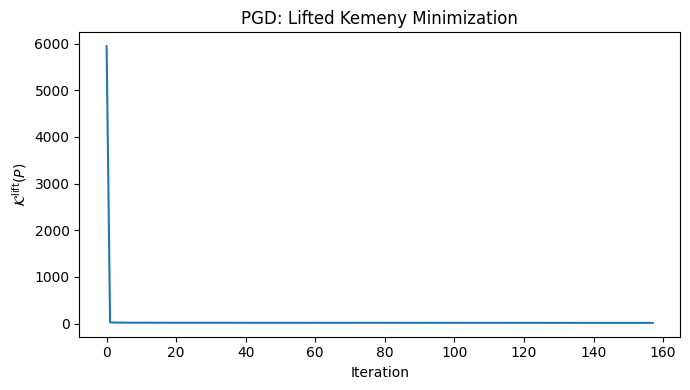

In [17]:
from graph import degree_lifting, random_chain
from optimize import _grad_lifted_kemeny, make_project_Q, projected_gradient_descent

# --- Degree lifting: node j gets deg(j) virtual states ---
V = degree_lifting(A)
n, m = V.shape

print(f"Physical nodes m={m}, lifted states n={n}")
# print("V:\n", V)

# --- Random initialization in the lifted space ---
eps = 1e-6
Q_opt_ceil = (Q_opt > eps).astype(int)
A_lift = V @ Q_opt_ceil @ V.T
print("A_lift:\n", A_lift.astype(int))
Q_lift_init = random_chain(A_lift, seed=seed)

# Project onto the feasible lifting set of Q_opt (Eq. 34)
project_fn_lift = make_project_Q(Q_opt, V)
Q_lift_0 = project_fn_lift(Q_lift_init)

val_init, _ = _grad_lifted_kemeny(Q_lift_0, V, pi_bar)
K_opt, _ = _grad_kemeny(Q_opt)
print(f"\nK^lift (initial):    {val_init:.4f}")
print(f"K(Q_opt) [upper bd]: {K_opt:.4f}")

# --- PGD to minimize K^lift subject to Q being a lifting of Q_opt ---
grad_fn_lift = lambda Q: _grad_lifted_kemeny(Q, V, pi_bar)
Q_lift_opt, history_lift = projected_gradient_descent(
    Q_lift_0, grad_fn_lift, project_fn_lift, alpha=1e-5, n_iter=100, tol=1e-2
)

print(f"\nK^lift initial:  {history_lift[0]:.4f}")
print(f"K^lift final:    {history_lift[-1]:.4f}")
print(f"K(Q_opt):        {K_opt:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(history_lift)
plt.xlabel("Iteration")
plt.ylabel(r"$\mathcal{K}^\mathrm{lift}(P)$")
plt.title("PGD: Lifted Kemeny Minimization")
plt.tight_layout()
plt.show()


p = 0.20
  Stationary distribution pi:
    node 0: 0.042360
    node 1: 0.098934
    node 2: 0.144582
    node 3: 0.096532
    node 4: 0.058275
    node 5: 0.151672
    node 6: 0.076713
    node 7: 0.042829
    node 8: 0.145621
    node 9: 0.142483

p = 0.40
  Stationary distribution pi:
    node 0: 0.104423
    node 1: 0.046200
    node 2: 0.156196
    node 3: 0.155716
    node 4: 0.094940
    node 5: 0.039249
    node 6: 0.132251
    node 7: 0.115983
    node 8: 0.078010
    node 9: 0.077033

p = 0.60
  Stationary distribution pi:
    node 0: 0.111900
    node 1: 0.180245
    node 2: 0.098102
    node 3: 0.053096
    node 4: 0.068507
    node 5: 0.117898
    node 6: 0.142794
    node 7: 0.068149
    node 8: 0.080169
    node 9: 0.079141

p = 0.80
  Stationary distribution pi:
    node 0: 0.133483
    node 1: 0.066546
    node 2: 0.072350
    node 3: 0.135613
    node 4: 0.105228
    node 5: 0.149314
    node 6: 0.041482
    node 7: 0.080998
    node 8: 0.069162
    node 9: 0.145823



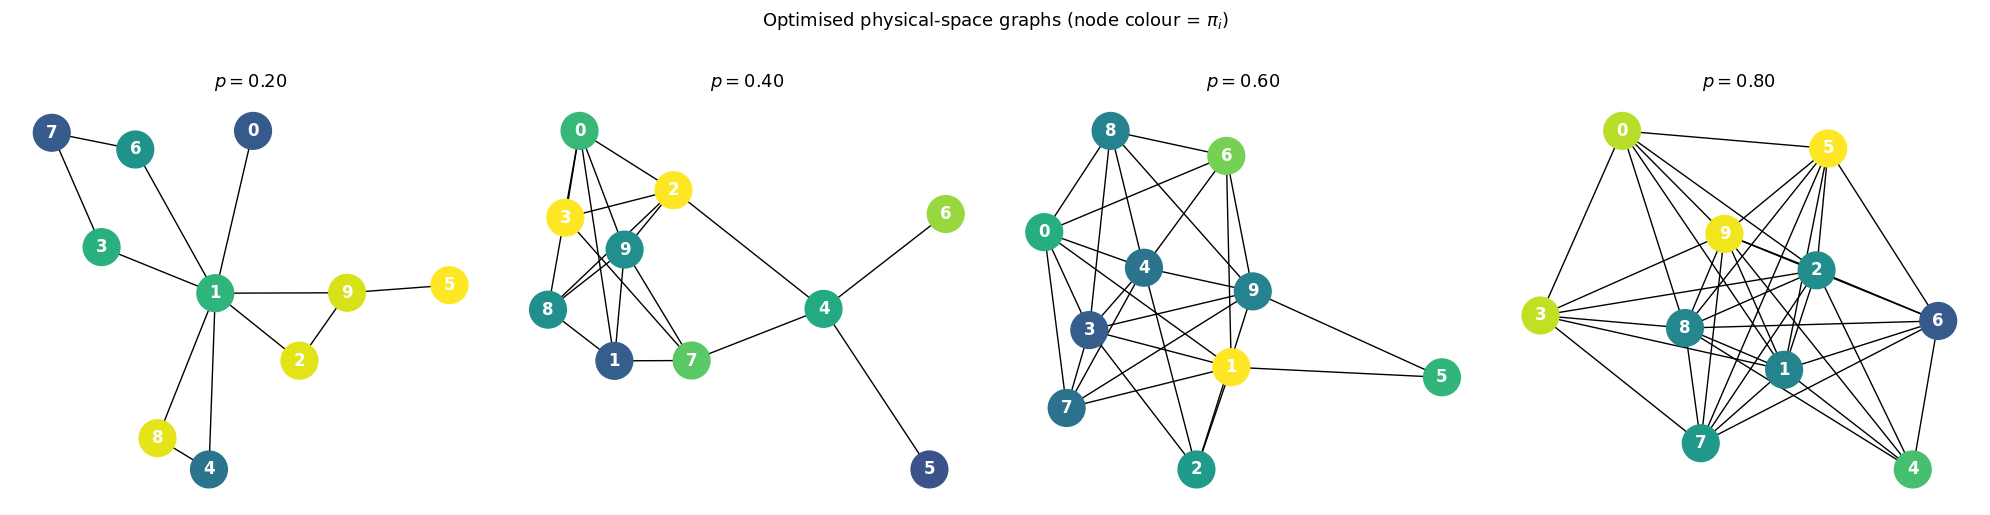

In [20]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

data = np.load("erdos_renyi_diffs.npy", allow_pickle=True).item()
p_values = data['p_values']
all_graphs = data['graphs']
all_Q_bar  = data['Q_bar']

fig, axes = plt.subplots(1, len(p_values), figsize=(5 * len(p_values), 5))
if len(p_values) == 1:
    axes = [axes]

for ax, p, graphs, Q_bars in zip(axes, p_values, all_graphs, all_Q_bar):
    for A, Q_bar in zip(graphs, Q_bars):
        # stationary distribution: row sums of ergodic flow matrix Q_bar
        pi = Q_bar.sum(axis=1)

        print(f"p = {p:.2f}")
        print("  Stationary distribution pi:")
        for i, pi_i in enumerate(pi):
            print(f"    node {i}: {pi_i:.6f}")
        print()

        G = nx.from_numpy_array(A - np.diag(np.diag(A)))  # drop self-loops for layout
        pos = nx.spring_layout(G, seed=0)
        node_colors = pi / pi.max()

        nx.draw_networkx(
            G, pos=pos, ax=ax,
            node_color=node_colors, cmap='viridis',
            node_size=700, font_color='white', font_weight='bold',
            vmin=0, vmax=1,
        )
        ax.set_title(f'$p = {p:.2f}$', fontsize=13)
        ax.axis('off')

plt.suptitle('Optimised physical-space graphs (node colour = $\\pi_i$)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
